In [ ]:
# Importing neccesary libraries
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Reading the dataset
dataset = pd.read_csv("data/smartphones.csv")
dataset.sample(5)

,Smartphone,Brand,Model,RAM,Storage,Color,Free,Final Price
1377,Honor 70 5G 8/128GB Negro Libre,Honor,70,8.0,128.0,Black,Yes,566.43
197,OPPO A98 5G 8/256GB Negro Libre,OPPO,A98,8.0,256.0,Black,Yes,386.60
834,Samsung Galaxy A32 5G 4/64GB Negro Libre Versi...,Samsung,Galaxy A32,4.0,64.0,Black,Yes,254.72
1006,Samsung Galaxy S22 5G 128GB Verde Libre Versió...,Samsung,Galaxy S22,NaN,128.0,Green,Yes,716.13
755,Realme 9 Pro 5G 8/128GB Verde Libre,Realme,9 Pro,8.0,128.0,Green,Yes,352.59


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Smartphone   1816 non-null   str    
 1   Brand        1816 non-null   str    
 2   Model        1816 non-null   str    
 3   RAM          1333 non-null   float64
 4   Storage      1791 non-null   float64
 5   Color        1816 non-null   str    
 6   Free         1816 non-null   str    
 7   Final Price  1816 non-null   float64
dtypes: float64(3), str(5)
memory usage: 113.6 KB


In [4]:
dataset.describe()

,RAM,Storage,Final Price
count,1333.00000,1791.000000,1816.000000
mean,5.96099,162.652150,492.175573
std,2.66807,139.411605,398.606183
min,1.00000,2.000000,60.460000
25%,4.00000,64.000000,200.990000
50%,6.00000,128.000000,349.990000
75%,8.00000,256.000000,652.717500
max,12.00000,1000.000000,2271.280000


In [5]:
print(dataset["Storage"].value_counts())
print("-------------------------------")
print(dataset["RAM"].value_counts())

Storage
128.0     732
256.0     412
64.0      332
32.0      166
512.0      94
16.0       24
1000.0     17
4.0         6
8.0         3
2.0         2
3.0         2
12.0        1
Name: count, dtype: int64
-------------------------------
RAM
8.0     381
4.0     380
6.0     259
3.0     112
12.0    109
2.0      88
1.0       4
Name: count, dtype: int64


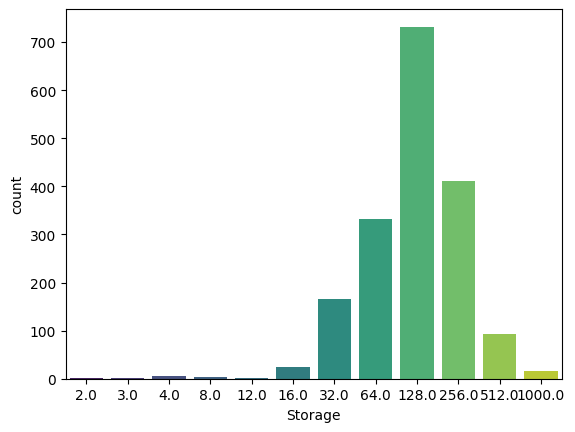

In [6]:
s_Storage = sns.countplot(x="Storage", data=dataset, palette="viridis")


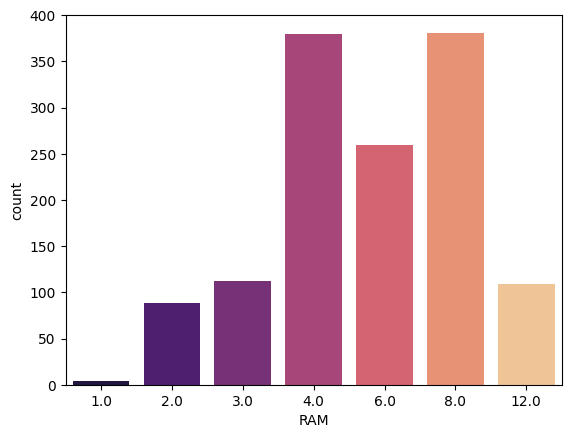

In [7]:
s_RAM = sns.countplot(x="RAM", data=dataset, palette="magma")

In [8]:
# Missing values
dataset.isnull().sum()

Smartphone       0
Brand            0
Model            0
RAM            483
Storage         25
Color            0
Free             0
Final Price      0
dtype: int64

In [9]:
def missing_values(dataset):
    total = dataset.isnull().sum().sort_values(ascending=False)
    percent = (dataset.isnull().sum()/dataset.isnull().count()).sort_values(ascending=False)
    return pd.concat([total, percent], axis=1, keys=["Total", "Percent"])

missing_values(dataset)

,Total,Percent
RAM,483,0.265969
Storage,25,0.013767
Brand,0,0.000000
Smartphone,0,0.000000
Model,0,0.000000
Color,0,0.000000
Free,0,0.000000
Final Price,0,0.000000


In [13]:
imputer = KNNImputer(n_neighbors=2, weights="uniform")

In [14]:
dataset[["Storage", "RAM"]] = imputer.fit_transform(dataset[["Storage", "RAM"]])

In [15]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Smartphone   1816 non-null   str    
 1   Brand        1816 non-null   str    
 2   Model        1816 non-null   str    
 3   RAM          1816 non-null   float64
 4   Storage      1816 non-null   float64
 5   Color        1816 non-null   str    
 6   Free         1816 non-null   str    
 7   Final Price  1816 non-null   float64
dtypes: float64(3), str(5)
memory usage: 113.6 KB


In [16]:
dataset.to_csv("data/smartphones_imputed.csv", index=False)
